## TODO

so what i am gonna do is measure the mahalanobois distance between the class latent vector centers and if a new sample's latent vector falls far away from all the known class centers than i say that it is ood even if it has a 99% confidence in softmax and this check can be added to this function in Exp_Classification

For OOD detection:
- ODIN
- Mahalanobois distance

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [49]:
data_name = "WISDM"

id_results = np.load(f"./analysis_results/{data_name}_n3_h2_id_v3_new-odin-calc.npz")
id_results = {key: id_results[key] for key in id_results.files}

ood_results = np.load(f"./analysis_results/{data_name}_n3_h2_ood_v3_new-odin-calc.npz")
ood_results = {key: ood_results[key] for key in ood_results.files}



id_results['max_logit'] = np.max(id_results['logits'], axis=1)
ood_results['max_logit'] = np.max(ood_results['logits'], axis=1)

In [50]:
def add_entropy_to_results(results):
    probs = results['probs']
    
    # Calculate Entropy: -sum(p * log(p))
    # axis=1 performs the sum across the classes for each sample
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    
    results['entropy'] = entropy
    
    # For AUROC functions that expect Higher = ID:
    # Use negative entropy (because we want ID to be the "higher" score)
    results['neg_entropy'] = -entropy
    
    return results

# Apply to your data
id_results = add_entropy_to_results(id_results)
ood_results = add_entropy_to_results(ood_results)

In [51]:
def add_energy_to_results(results, T=1.0):
    logits = torch.from_numpy(results['logits'])
    # Energy = -T * log(sum(exp(logit/T)))
    energy = -T * torch.logsumexp(logits / T, dim=1).numpy()
    results['energy'] = energy
    return results


temperature = 1.0

id_res = add_energy_to_results(id_results, T=temperature)
ood_res = add_energy_to_results(ood_results, T=temperature)

In [52]:
def apply_custom_thresholds(results, msp_thresh=0.7, mahal_thresh=15.0, odin_thresh=0.8):
    # MSP: Flag as OOD if confidence is BELOW threshold
    results['is_ood_msp'] = results['max_conf'] < msp_thresh
    
    # Mahalanobis: Flag as OOD if distance is ABOVE threshold
    results['is_ood_mahal'] = results['mahal_distance'] > mahal_thresh
    
    # ODIN: Flag as OOD if sharpened score is BELOW threshold
    results['is_ood_odin'] = results['odin_score'] < odin_thresh
    
    return results



In [53]:
analysis_results = {}

keys = id_results.keys()
for key in keys:
    analysis_results[key] = np.concatenate([id_results[key], ood_results[key]], axis=0)

In [54]:
analysis_results['targets'].shape, analysis_results['preds'].shape

((819,), (819,))

In [55]:
id_acc = np.sum(id_results['targets'] == id_results['preds']) / len(id_results['targets'])
ood_acc = np.sum(ood_results['targets'] == ood_results['preds']) / len(ood_results['targets'])
analysis_acc = np.sum(analysis_results['targets'] == analysis_results['preds']) / len(analysis_results['targets'])

print(f"ID Accuracy:       {id_acc:.4f}")
print(f"OOD Accuracy:      {ood_acc:.4f}")
print(f"Combined Accuracy: {analysis_acc:.4f}")

ID Accuracy:       0.8138
OOD Accuracy:      0.0000
Combined Accuracy: 0.4750


In [56]:
analysis_results.get("max_conf").max()

0.9985538

In [57]:
analysis_results.keys()

dict_keys(['latents', 'logits', 'probs', 'targets', 'preds', 'max_conf', 'mahal_distance', 'odin_score', 'max_logit', 'entropy', 'neg_entropy', 'energy'])

# Plot functions

In [72]:
def plot_score_distributions(id_results, ood_results, score_type='max_conf', density=False):
    """
    Compares the distribution of scores between In-Distribution and OOD data.
    
    Args:
        id_results (dict): Dictionary containing ID scores.
        ood_results (dict): Dictionary containing OOD scores.
        score_type (str): The key for the score to plot.
        density (bool): If True, plots probability density. If False, plots raw counts.
    """
    id_scores = id_results[score_type]
    ood_scores = ood_results[score_type]
    
    plt.figure(figsize=(10, 6))
    
    # Define common bins for both datasets
    bins = np.linspace(min(id_scores.min(), ood_scores.min()), 
                       max(id_scores.max(), ood_scores.max()), 50)
    
    # Plotting histograms
    plt.hist(id_scores, bins=bins, alpha=0.5, label='In-Distribution', 
             color='skyblue', edgecolor='navy', density=density)
    plt.hist(ood_scores, bins=bins, alpha=0.5, label='Out-of-Distribution', 
             color='salmon', edgecolor='darkred', density=density)
    
    plt.title(f'OOD Detection Analysis: {score_type.upper()} Distribution', fontsize=14)
    plt.xlabel('Confidence Score', fontsize=12)
    
    # Dynamically update the Y-axis label
    ylabel = 'Probability Density' if density else 'Frequency (Count)'
    plt.ylabel(ylabel, fontsize=12)
    
    plt.legend(loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [59]:
def plot_per_class_confidence(analysis_results, column='max_conf'):
    """
    Shows the distribution of max_conf for every class in the results.
    Useful for seeing which known classes are 'overconfident'.
    """
    targets = analysis_results['targets']
    confidences = analysis_results[column]
    unique_classes = sorted(np.unique(targets))
    
    data_to_plot = [confidences[targets == cls] for cls in unique_classes]
    
    plt.figure(figsize=(12, 6))
    plt.boxplot(data_to_plot, patch_artist=True, 
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2))
    
    plt.xticks(range(1, len(unique_classes) + 1), [f"Class {int(c)}" for c in unique_classes])
    plt.title('Confidence Variation across Classes', fontsize=14)
    plt.ylabel(f'{column.upper()}', fontsize=12)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()

In [60]:
def plot_reliability_curve(analysis_results, n_bins=10):
    """
    Plots expected calibration: Accuracy vs. Confidence.
    """
    confidences = analysis_results['max_conf']
    targets = analysis_results['targets']
    preds = analysis_results['preds']
    accuracies = (preds == targets)
    
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_accs = []
    bin_confs = []
    
    for i in range(n_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        if np.any(mask):
            bin_accs.append(np.mean(accuracies[mask]))
            bin_confs.append(np.mean(confidences[mask]))
            
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')
    plt.plot(bin_confs, bin_accs, marker='o', linewidth=2, color='darkorange', label='Model')
    
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Reliability Diagram')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

In [61]:
# The probability that a random ID sample gets a higher score than a random OOD sample.

def plot_auroc_manual(id_results, ood_results, score_type='max_conf'):
    """
    Calculates and plots AUROC without sklearn.
    id_results: dict from get_detailed_analysis_dict (In-Distribution)
    ood_results: dict from get_detailed_analysis_dict (Out-Of-Distribution)
    score_type: 'max_conf' or 'energy'
    """
    # Extract the score arrays
    id_scores = id_results[score_type]
    ood_scores = ood_results[score_type]
    
    # 1. Combine all scores to find every potential threshold
    all_scores = np.concatenate([id_scores, ood_scores])
    
    # unique_scores is the set of all confidence values the model actually produced
    unique_scores = np.unique(all_scores)
    
    # Sort thresholds from high (1.0) to low (0.0)
    thresholds = np.sort(unique_scores)[::-1]
    
    tpr_list = []
    fpr_list = []
    
    n_id = len(id_scores)
    n_ood = len(ood_scores)
    
    # 2. Sweep through thresholds to calculate TPR and FPR
    for t in thresholds:
        # True Positives: ID samples correctly identified as ID (score >= threshold)
        tp = np.sum(id_scores >= t)
        # False Positives: OOD samples incorrectly identified as ID (score >= threshold)
        fp = np.sum(ood_scores >= t)
        
        tpr_list.append(tp / n_id)
        fpr_list.append(fp / n_ood)
    
    # Convert to arrays for calculation
    tpr = np.array(tpr_list)
    fpr = np.array(fpr_list)
    
    # 3. Calculate AUROC using the Trapezoidal Rule
    # This integrates the area under the TPR-FPR curve
    auc_score = np.trapz(tpr, fpr)

    # 4. Plotting
    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (area = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (OOD accepted as ID)')
    plt.ylabel('True Positive Rate (ID correctly accepted)')
    plt.title(f'OOD Detection Performance: {score_type}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()

    return auc_score

In [62]:
def plot_latent_clusters(analysis_results, method='tsne', title="TimeDRL Latent Space Visualization", **kwargs):
    """
    Reduces high-dimensional latents to 2D using PCA or t-SNE and plots them.
    
    Args:
        analysis_results: Dict containing 'latents' (N, D) and 'targets' (N,).
        method: 'pca' or 'tsne'.
        title: Custom plot title string.
        **kwargs: Arguments passed to the reduction class (e.g., perplexity=50).
    """
    latents = analysis_results['latents']
    targets = analysis_results['targets']
    method = method.lower()
    
    # 1. Initialize the Engine
    if method == 'pca':
        # PCA is deterministic, usually doesn't need a random_state unless using svd_solver='arpack'
        model = PCA(n_components=3, **kwargs)
    elif method == 'tsne':
        # Default t-SNE settings if not provided in kwargs
        params = {'perplexity': 30, 'init': 'pca', 'learning_rate': 'auto', 'random_state': 42}
        params.update(kwargs)
        model = TSNE(n_components=2, **params)
    else:
        raise ValueError("Method must be 'pca' or 'tsne'")

    # 2. Run Reduction
    print(f"Reducing {latents.shape[1]}D to 2D using {method.upper()}...")
    latents_2d = model.fit_transform(latents)
    
    # 3. Plotting
    plt.figure(figsize=(10, 7))
    unique_classes = np.unique(targets)
    
    for cls in unique_classes:
        idx = (targets == cls)
        plt.scatter(
            latents_2d[idx, 0], 
            latents_2d[idx, 1], 
            label=f"Class {int(cls)}",
            alpha=0.6, 
            edgecolors='w',
            s=30
        )
    
    # Dynamic titling and labeling
    chart_title = title or f"TimeDRL Latent Space ({method.upper()})"
    plt.title(chart_title)
    plt.xlabel(f"{method.upper()} Component 1")
    plt.ylabel(f"{method.upper()} Component 2")
    
    plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [63]:
def find_optimal_threshold(id_results, ood_results, score_type='max_conf'):
    id_scores = id_results[score_type]
    ood_scores = ood_results[score_type]
    
    thresholds = np.linspace(0, 1, 100)
    best_j = -1
    opt_t = 0
    
    for t in thresholds:
        tpr = np.sum(id_scores >= t) / len(id_scores)
        fpr = np.sum(ood_scores >= t) / len(ood_scores)
        j = tpr - fpr
        if j > best_j:
            best_j = j
            opt_t = t
            
    print(f"Optimal threshold for {score_type}: {opt_t:.4f}")
    return opt_t

In [64]:
# tpr = id as id / all id
# fpr = ood as id / all ood

def plot_fpr95_metric(id_results, ood_results, score_type='max_conf'):
    """
    Calculates and visualizes the FPR at 95% TPR.
    Note: For 'energy', ensure you pass neg_energy so that higher = ID.
    """
    id_scores = np.sort(id_results[score_type])
    ood_scores = ood_results[score_type]
    
    # 1. Find the threshold for 95% TPR
    # To keep 95% of ID, we find the 5th percentile of ID scores
    # (Since scores are sorted ascending, 5% of the way in is the cutoff)
    threshold_95tpr = np.percentile(id_scores, 5)
    
    # 2. Calculate FPR at this threshold
    # FPR = (OOD samples >= threshold) / (Total OOD samples)
    fps = np.sum(ood_scores >= threshold_95tpr)
    fpr95 = (fps / len(ood_scores)) * 100
    
    # 3. Visualization
    plt.figure(figsize=(10, 6))
    
    # Plot histograms
    bins = np.linspace(min(id_scores.min(), ood_scores.min()), 
                       max(id_scores.max(), ood_scores.max()), 50)
    
    plt.hist(id_scores, bins=bins, alpha=0.5, label='ID Scores', color='blue', density=True)
    plt.hist(ood_scores, bins=bins, alpha=0.5, label='OOD Scores', color='red', density=True)
    
    # Draw the 95% TPR Threshold line
    plt.axvline(threshold_95tpr, color='black', linestyle='--', linewidth=2, 
                label=f'Threshold (95% TPR): {threshold_95tpr:.4f}')
    
    # Highlight the "Leakage" area (OOD samples above threshold)
    plt.fill_betweenx([0, plt.gca().get_ylim()[1]], threshold_95tpr, bins.max(), 
                      color='red', alpha=0.1, label='OOD Leakage (FPR)')
    
    plt.title(f'FPR at 95% TPR: {fpr95:.2f}%', fontsize=14)
    plt.xlabel(f'Score ({score_type})')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    print(f"--- OOD Metric: {score_type} ---")
    print(f"Threshold for 95% TPR: {threshold_95tpr:.4f}")
    print(f"FPR at 95% TPR: {fpr95:.2f}%")
    
    return fpr95

In [65]:
def plot_confusion_matrix_manual(results, class_names=None):
    """
    Creates a heatmap of predictions vs targets.
    results: dict containing 'preds' and 'targets'
    class_names: list of strings (e.g., ['Walk', 'Sit', 'Run', 'Stand'])
    """
    y_true = results['targets']
    y_pred = results['preds']
    
    # 1. Identify unique classes (e.g., [0, 1, 4, 5])
    unique_classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(unique_classes)
    
    # 2. Initialize the matrix
    cm = np.zeros((n_classes, n_classes), dtype=int)
    
    # 3. Fill the matrix
    # Map class IDs to matrix indices (0, 1, 2, 3)
    class_to_idx = {val: i for i, val in enumerate(unique_classes)}
    
    for t, p in zip(y_true, y_pred):
        cm[class_to_idx[t], class_to_idx[p]] += 1
    
    # 4. Plotting
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()
    
    tick_marks = np.arange(n_classes)
    display_labels = class_names if class_names else [f"Class {c}" for c in unique_classes]
    
    plt.xticks(tick_marks, display_labels, rotation=45)
    plt.yticks(tick_marks, display_labels)
    
    # Add text annotations inside the cells
    thresh = cm.max() / 2.
    for i in range(n_classes):
        for j in range(n_classes):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Plot results

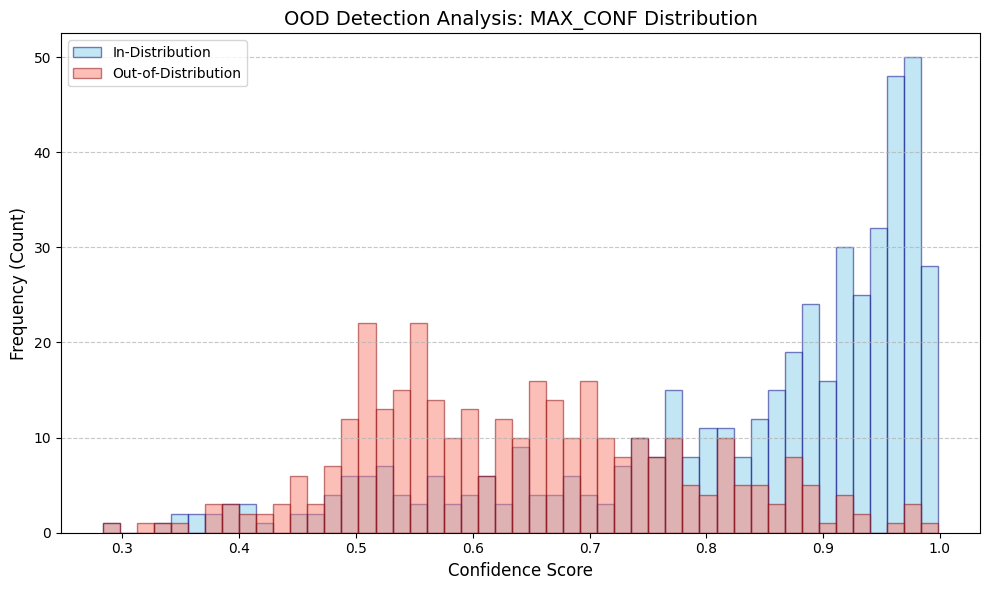

In [78]:
plot_score_distributions(id_results, ood_results, score_type='max_conf')

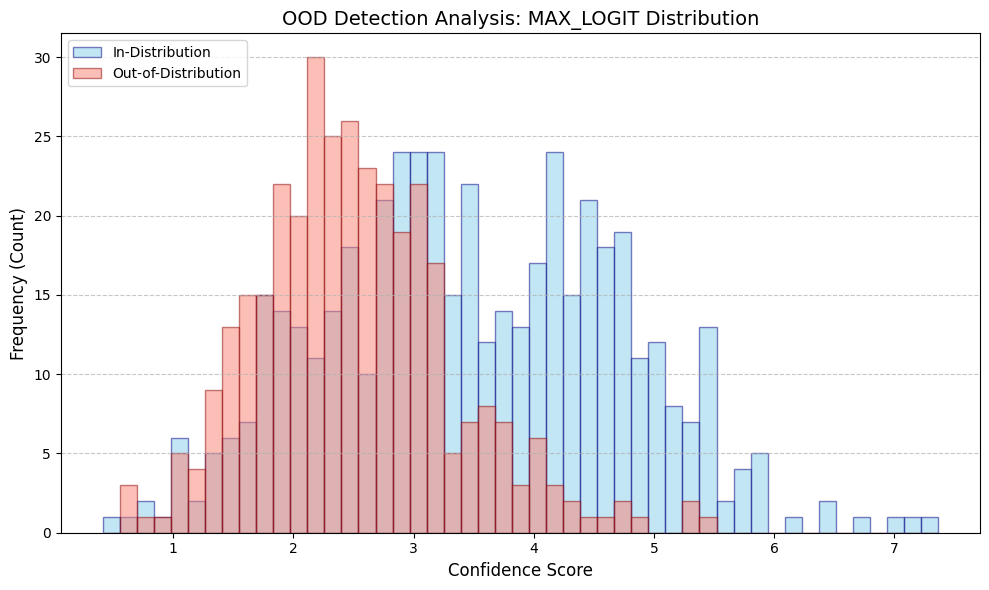

In [79]:
plot_score_distributions(id_results, ood_results, score_type='max_logit')

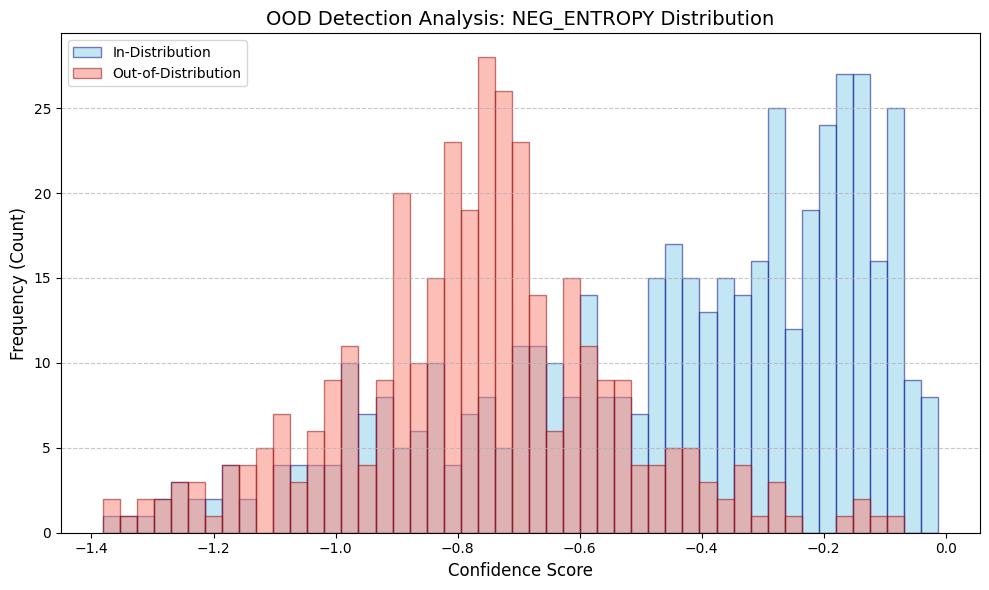

In [80]:
plot_score_distributions(id_results, ood_results, score_type='neg_entropy')

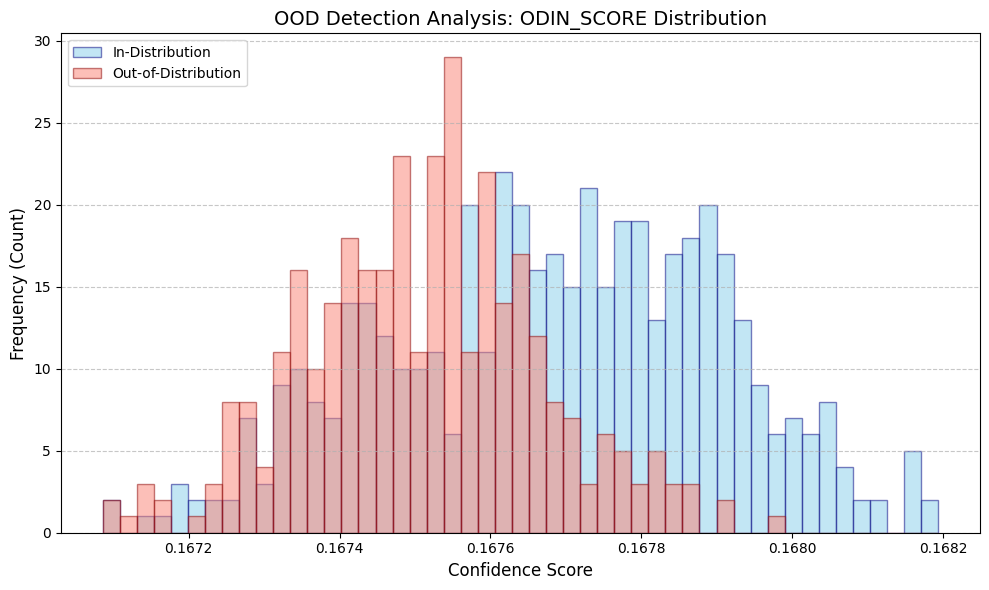

In [81]:
plot_score_distributions(id_results, ood_results, score_type='odin_score')

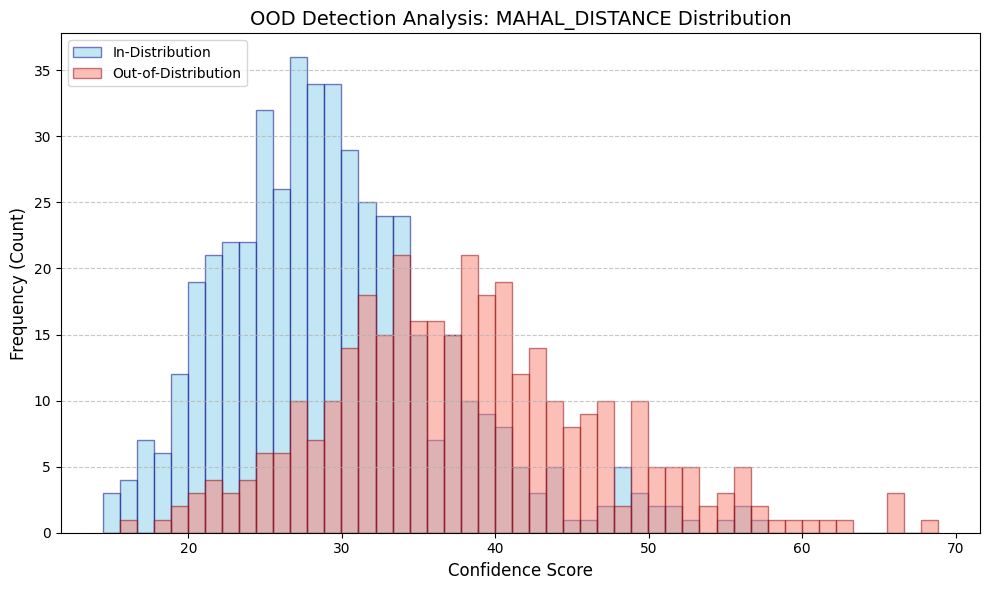

In [82]:
plot_score_distributions(id_results, ood_results, score_type='mahal_distance')

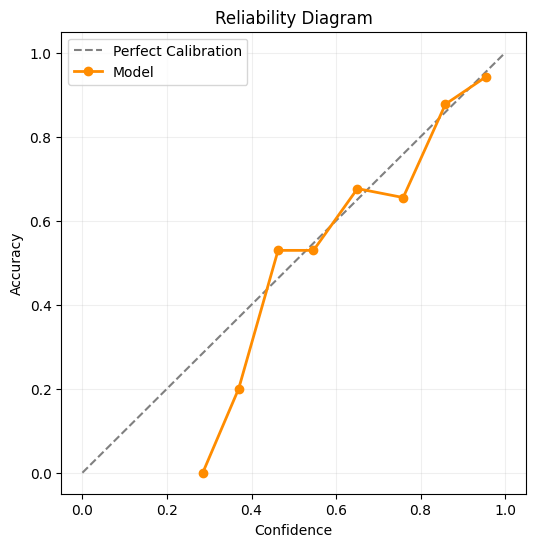

In [83]:
plot_reliability_curve(id_results)

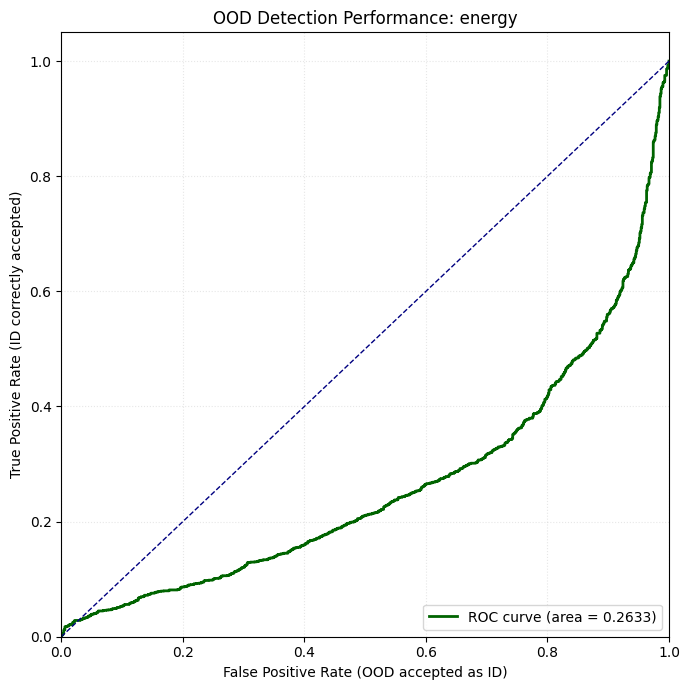

0.2632580653102421

In [34]:
# Which metric separates id and ood samples the best???

plot_auroc_manual(id_results, ood_results, score_type='energy')

Reducing 256D to 2D using PCA...


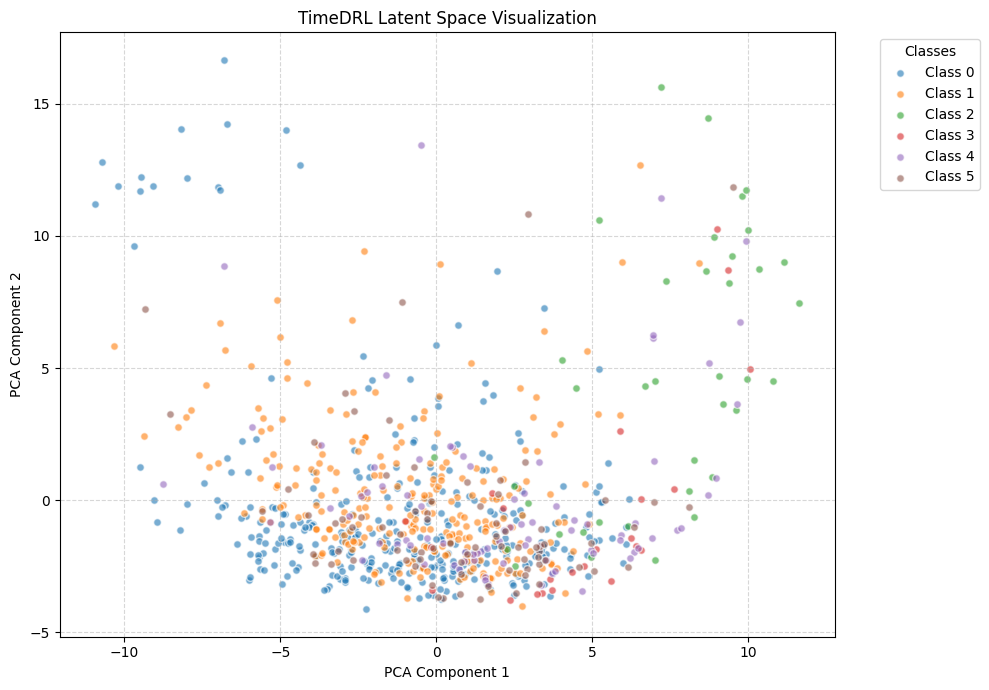

In [84]:
plot_latent_clusters(analysis_results, method='pca')

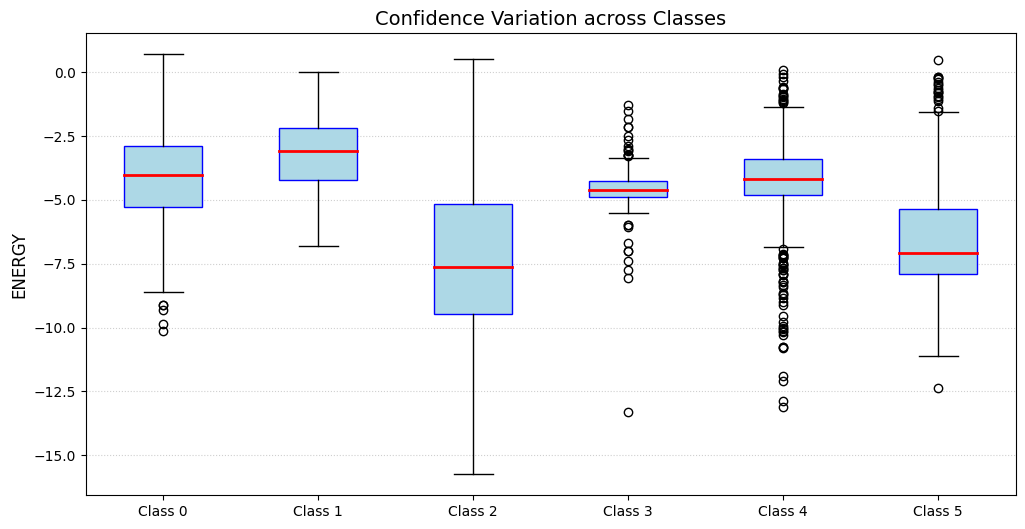

In [42]:
plot_per_class_confidence(analysis_results, column='energy')

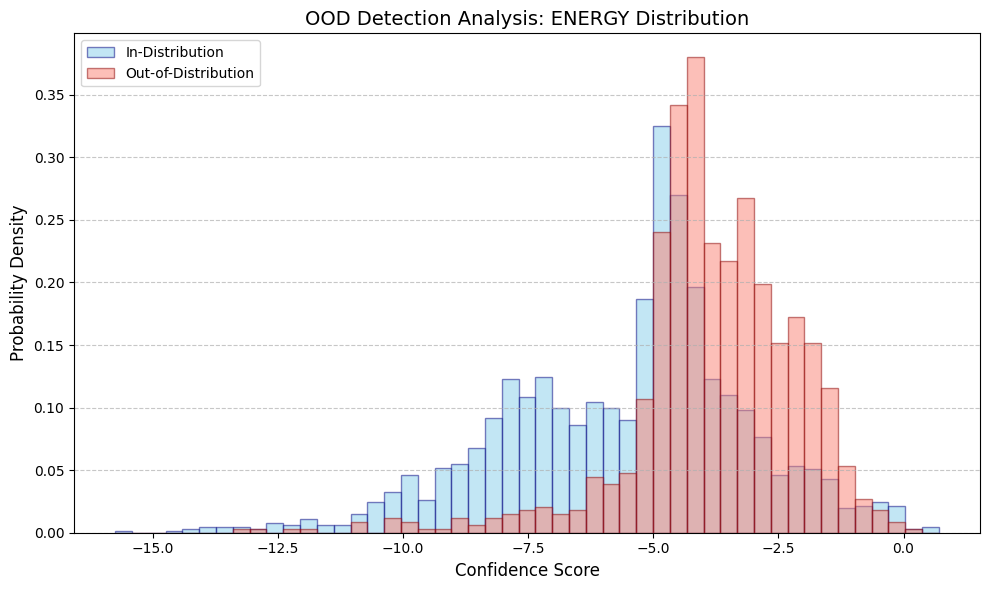

In [35]:
plot_score_distributions(id_results, ood_results, score_type='energy')

In [164]:
find_optimal_threshold(id_results, ood_results, score_type='max_conf')

Optimal threshold for max_conf: 0.7677


0.7676767676767677

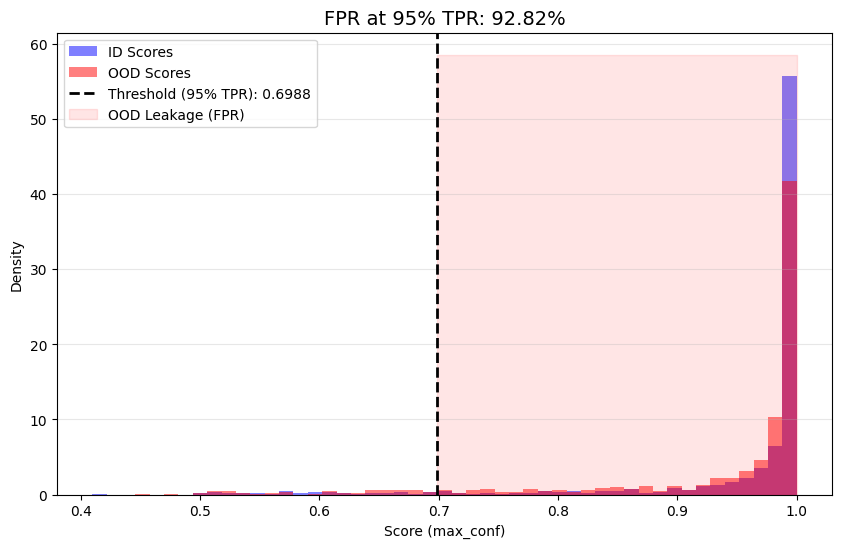

--- OOD Metric: max_conf ---
Threshold for 95% TPR: 0.6988
FPR at 95% TPR: 92.82%


92.82153539381855

In [39]:
plot_fpr95_metric(id_results, ood_results, score_type='max_conf')

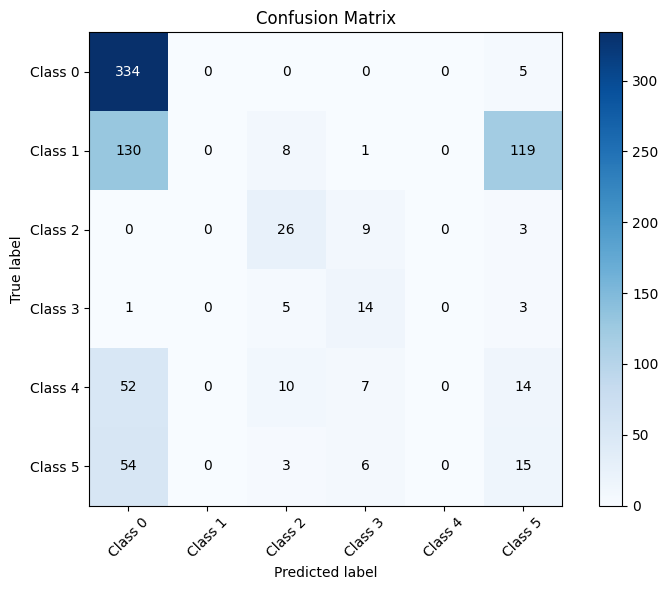

In [166]:
plot_confusion_matrix_manual(analysis_results)